In [1]:
import sys
from pathlib import Path

import numpy as np
import networkx as nx
from bayesian_order_based_learning.metrics import *

sys.path.append(str(Path.cwd().parent / "bayesian_order_based_learning"))

In [2]:
from simulation.simulation import Simulation

/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-26 20:53:36,693	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [15]:
p = 10
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([0, 8, 4, 1, 3, 6, 7, 2, 5, 9])

In [39]:
sim = Simulation(sigma=sigma, n_k=200, K_list=[1,5,10,100], verbose=True)
predicted_orderings, predicted_dags, log_posteriors = sim.simulate()
true_dags = sim.get_true_dags()
true_posterior = sim.get_true_posterior()

2026-08-26 23:09:58,662	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-26 23:09:58,676	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-26 23:09:58,680	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_34749e4c0da86eed.zip' (0.01MiB) to Ray cluster...
2026-08-26 23:09:58,681	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_34749e4c0da86eed.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:05<00:00, 377.32it/s]
2026-08-26 23:10:08,310	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-26 23:10:08,320	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-26 23:10:08,324	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_34749e4c0da86eed.zip' (0.01MiB) to Ray cluster...

In [40]:
tau_star_K1 = rank_correlation(predicted_orderings[0], sigma)
tau_star_K5 = rank_correlation(predicted_orderings[1], sigma)
tau_star_K10 = rank_correlation(predicted_orderings[2], sigma)
tau_star_K20 = rank_correlation(predicted_orderings[3], sigma)

In [41]:
tau_star_K1, tau_star_K5, tau_star_K10, tau_star_K20

(np.float64(0.09315555555555564),
 np.float64(0.0776444444444446),
 np.float64(0.06902222222222246),
 np.float64(0.023199999999999978))

In [42]:
def get_adj_matrix(list_dags):
    return [nx.adjacency_matrix(dag) for dag in list_dags]

true_adj_matrices = np.array(get_adj_matrix(true_dags[0]))
true_adj_matrices2 = np.array(get_adj_matrix(true_dags[1]))
true_adj_matrices3 = np.array(get_adj_matrix(true_dags[2]))
true_adj_matrices4 = np.array(get_adj_matrix(true_dags[3]))

predicted_adj_matrices = np.array([get_adj_matrix(dags) for dags in predicted_dags[0]])
predicted_adj_matrices2 = np.array([get_adj_matrix(dags) for dags in predicted_dags[1]])
predicted_adj_matrices3 = np.array([get_adj_matrix(dags) for dags in predicted_dags[2]])
predicted_adj_matrices4 = np.array([get_adj_matrix(dags) for dags in predicted_dags[3]])

In [43]:
hd = np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices])
hd2 = np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2])
hd3 = np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3])
hd4 = np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4])

In [44]:
hd, hd2, hd3, hd4

(np.float64(4.44375518181387),
 np.float64(3.780209502003753),
 np.float64(4.797967695178131),
 np.float64(5.308360043397719))

In [10]:
def find_edges(predicted_dags, true_dags):
    common_edges = [[] for _ in true_dags]
    diff_edges = [[] for _ in true_dags]
    edges_not_counted = [[] for _ in true_dags]

    for k, dag in enumerate(true_dags):
        temp = predicted_dags[-1][k]

        for e in temp.edges():
            if e in dag.edges():
                common_edges[k].append(e)
            else:
                diff_edges[k].append(e)

        for e in dag.edges():
            if e not in temp.edges():
                edges_not_counted[k].append(e)

    return common_edges, diff_edges, edges_not_counted


In [45]:
common_edges, diff_edges, edges_not_counted = find_edges(predicted_dags[0], true_dags[0])
print(f"Common edges: {common_edges}")
print(f"Different edges: {diff_edges}")
print(f"Unaccounted edges: {edges_not_counted}")

Common edges: [[(0, 2), (0, 6), (0, 7), (2, 5), (3, 2)]]
Different edges: [[]]
Unaccounted edges: [[]]


In [46]:
common_edges2, diff_edges2, edges_not_counted2 = find_edges(predicted_dags[1], true_dags[1])
print(f"Common edges: {common_edges2[0]}")
print(f"Different edges: {diff_edges2[0]}")
print(f"Unaccounted edges: {edges_not_counted2[0]}")

Common edges: [(0, 2), (0, 6), (0, 7), (2, 5), (3, 2)]
Different edges: []
Unaccounted edges: []


In [47]:
common_edges3, diff_edges3, edges_not_counted3 = find_edges(predicted_dags[2], true_dags[2])
print(f"Common edges: {common_edges3[0]}")
print(f"Different edges: {diff_edges3[0]}")
print(f"Unaccounted edges: {edges_not_counted3[0]}")

Common edges: [(0, 2), (0, 6), (0, 7), (2, 5), (3, 2)]
Different edges: []
Unaccounted edges: []


In [48]:
common_edges4, diff_edges4, edges_not_counted4 = find_edges(predicted_dags[3], true_dags[3])
print(f"Common edges: {common_edges4[0]}")
print(f"Different edges: {diff_edges4[0]}")
print(f"Unaccounted edges: {edges_not_counted4[0]}")

Common edges: [(0, 2), (0, 6), (0, 7), (2, 5), (3, 2)]
Different edges: []
Unaccounted edges: []


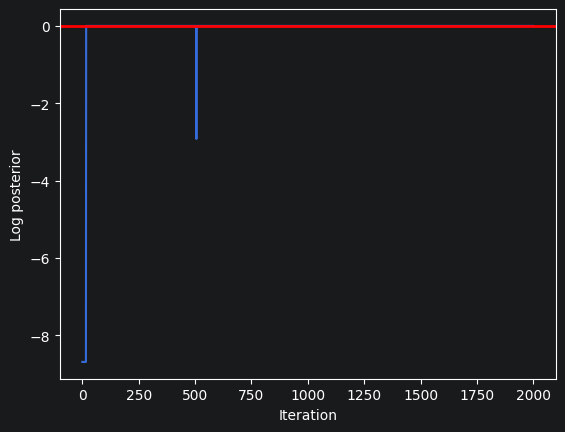

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(x=range(2001), y=(np.array(log_posteriors[0]) - true_posterior[0]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

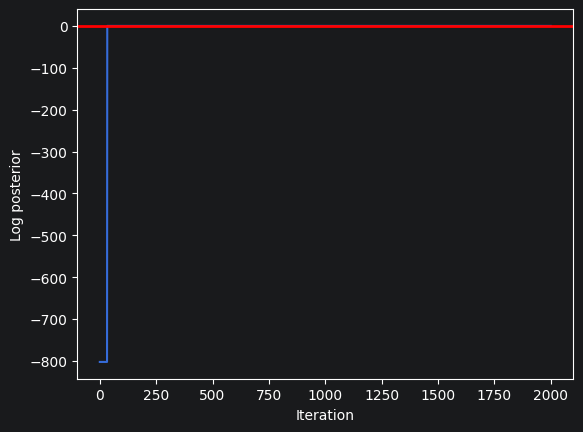

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(x=range(2001), y=(np.array(log_posteriors[3]) - true_posterior[3]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

In [43]:
log_posteriors[0][2], true_posterior[0]

(-34352.505877447344, -34352.505877447344)

In [60]:
print(log_posteriors[0][:5], log_posteriors[0][-5:])

[-34201.01032665854, -34201.01032665854, -34201.01032665854, -34201.01032665854, -34201.01032665854] [-34201.01032665854, -34201.01032665854, -34201.01032665854, -34201.01032665854, -34201.01032665854]
